In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression

In [2]:
import sys
sys.path.insert(0, "../../..")
from src.utils.orientation_utils import geodesic_error

In [3]:
df = pd.read_excel('../../../processed/splitted_train.xlsx')
df = df[df['object_id'] == 4]

In [4]:
X_cols = [
    'compactness_ext', 
    #'compactness_int', 
    #'compactness_total', 
    'dist_centroid', 
    'angle_centroid', 
    'sin_centroid', 
    'cos_centroid', 
    'aspect_ratio', 
    'eccentricity', 
    'sin_major', 
    'cos_major', 
    'hog_0_30', 
    'hog_30_60', 
    'hog_60_90', 
    'hog_90_120', 
    'hog_120_150', 
    'hog_150_180', 
    'hog_180_210', 
    'hog_210_240', 
    'hog_240_270', 
    'hog_270_300', 
    'hog_300_330', 
    'hog_330_360', 
    'hu_1', 
    'hu_2', 
    'hu_3', 
    'hu_4', 
    'hu_5', 
    'hu_6', 
    'hu_7'
]

y_cols = ['qw', 'qx', 'qy', 'qz']

In [5]:
train_df = df[df['set'] == 'train']
test_df = df[df['set'] == 'test']

X_train = train_df[X_cols]
y_train = train_df[y_cols]

X_test = test_df[X_cols]
y_test = test_df[y_cols]

In [6]:
from sklearn.preprocessing import PowerTransformer

pt_X = PowerTransformer(method='yeo-johnson', standardize=True)
pt_y = PowerTransformer(method='yeo-johnson', standardize=True)

X_train = pd.DataFrame(pt_X.fit_transform(X_train), columns=X_train.columns)
y_train = pd.DataFrame(pt_y.fit_transform(y_train), columns=y_train.columns)

X_test = pd.DataFrame(pt_X.transform(X_test), columns=X_test.columns)
y_test = pd.DataFrame(pt_y.transform(y_test), columns=y_test.columns)

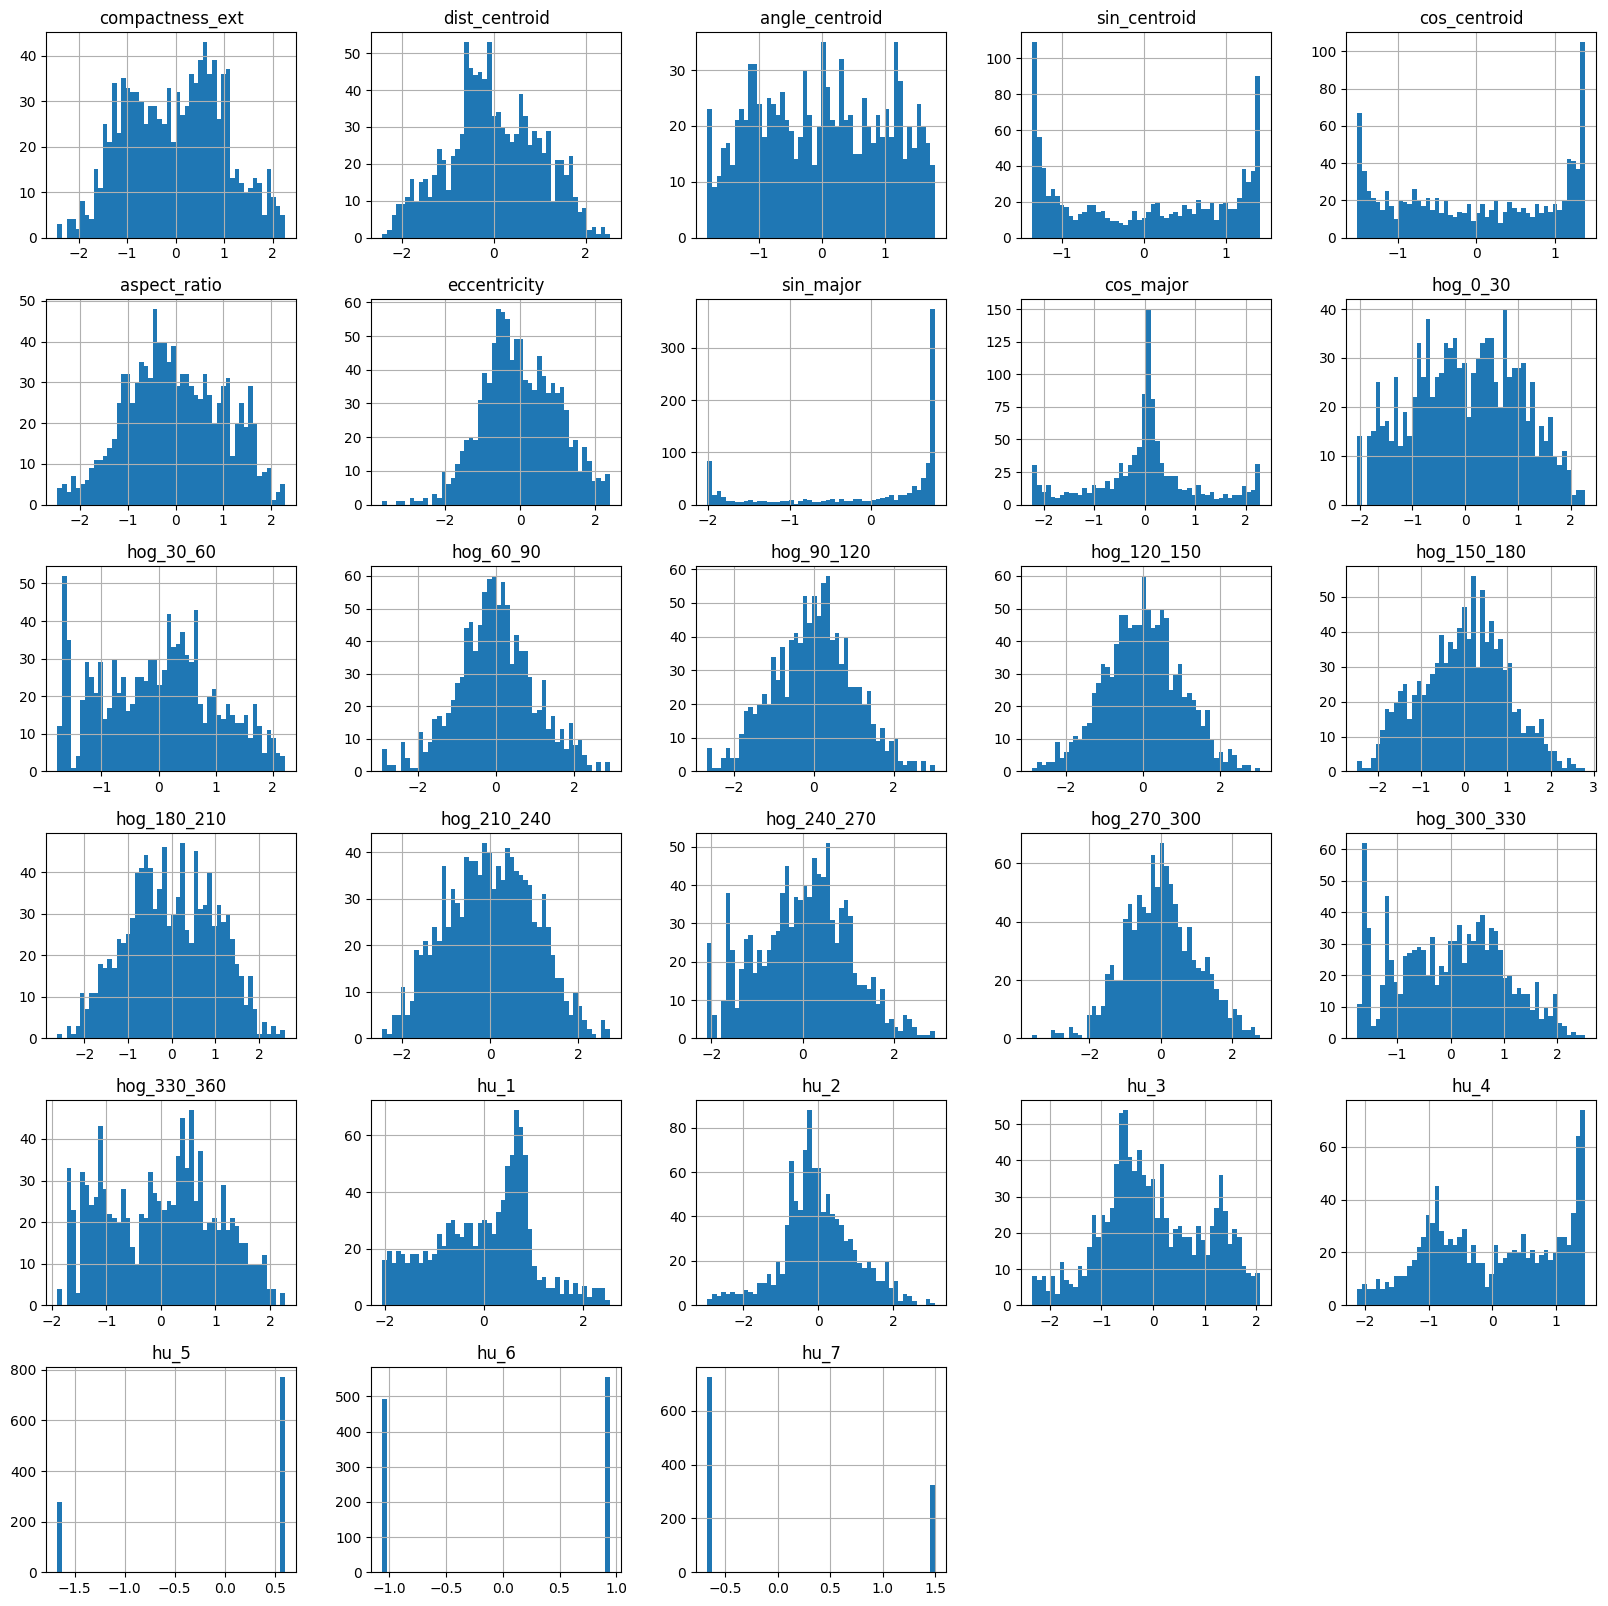

In [7]:
X_train.hist(figsize=(20, 20), bins=50)
plt.show()

In [8]:
X_train.describe().T

,count,mean,std,min,25%,50%,75%,max
compactness_ext,1050.0,-2.003054e-14,1.000477,-2.434931,-0.834005,0.047021,0.757718,2.244347
dist_centroid,1050.0,1.624098e-16,1.000477,-2.427363,-0.624515,-0.082702,0.739742,2.527593
angle_centroid,1050.0,-6.767074e-18,1.000477,-1.816566,-0.860091,0.027329,0.876056,1.797989
sin_centroid,1050.0,1.184238e-17,1.000477,-1.356369,-1.056174,0.056179,0.986751,1.412902
cos_centroid,1050.0,-5.413659e-17,1.000477,-1.514345,-0.903170,0.008307,1.019146,1.383762
aspect_ratio,1050.0,-7.579123e-16,1.000477,-2.467707,-0.724109,-0.070436,0.771105,2.282601
eccentricity,1050.0,-1.624098e-16,1.000477,-3.650550,-0.663197,-0.064673,0.730748,2.380241
sin_major,1050.0,1.624098e-16,1.000477,-2.008533,-0.621178,0.582593,0.761665,0.782922
cos_major,1050.0,2.368476e-17,1.000477,-2.223562,-0.437428,0.054425,0.346630,2.279078
hog_0_30,1050.0,-2.706829e-16,1.000477,-2.038769,-0.765373,0.002821,0.789841,2.262465


<Axes: >

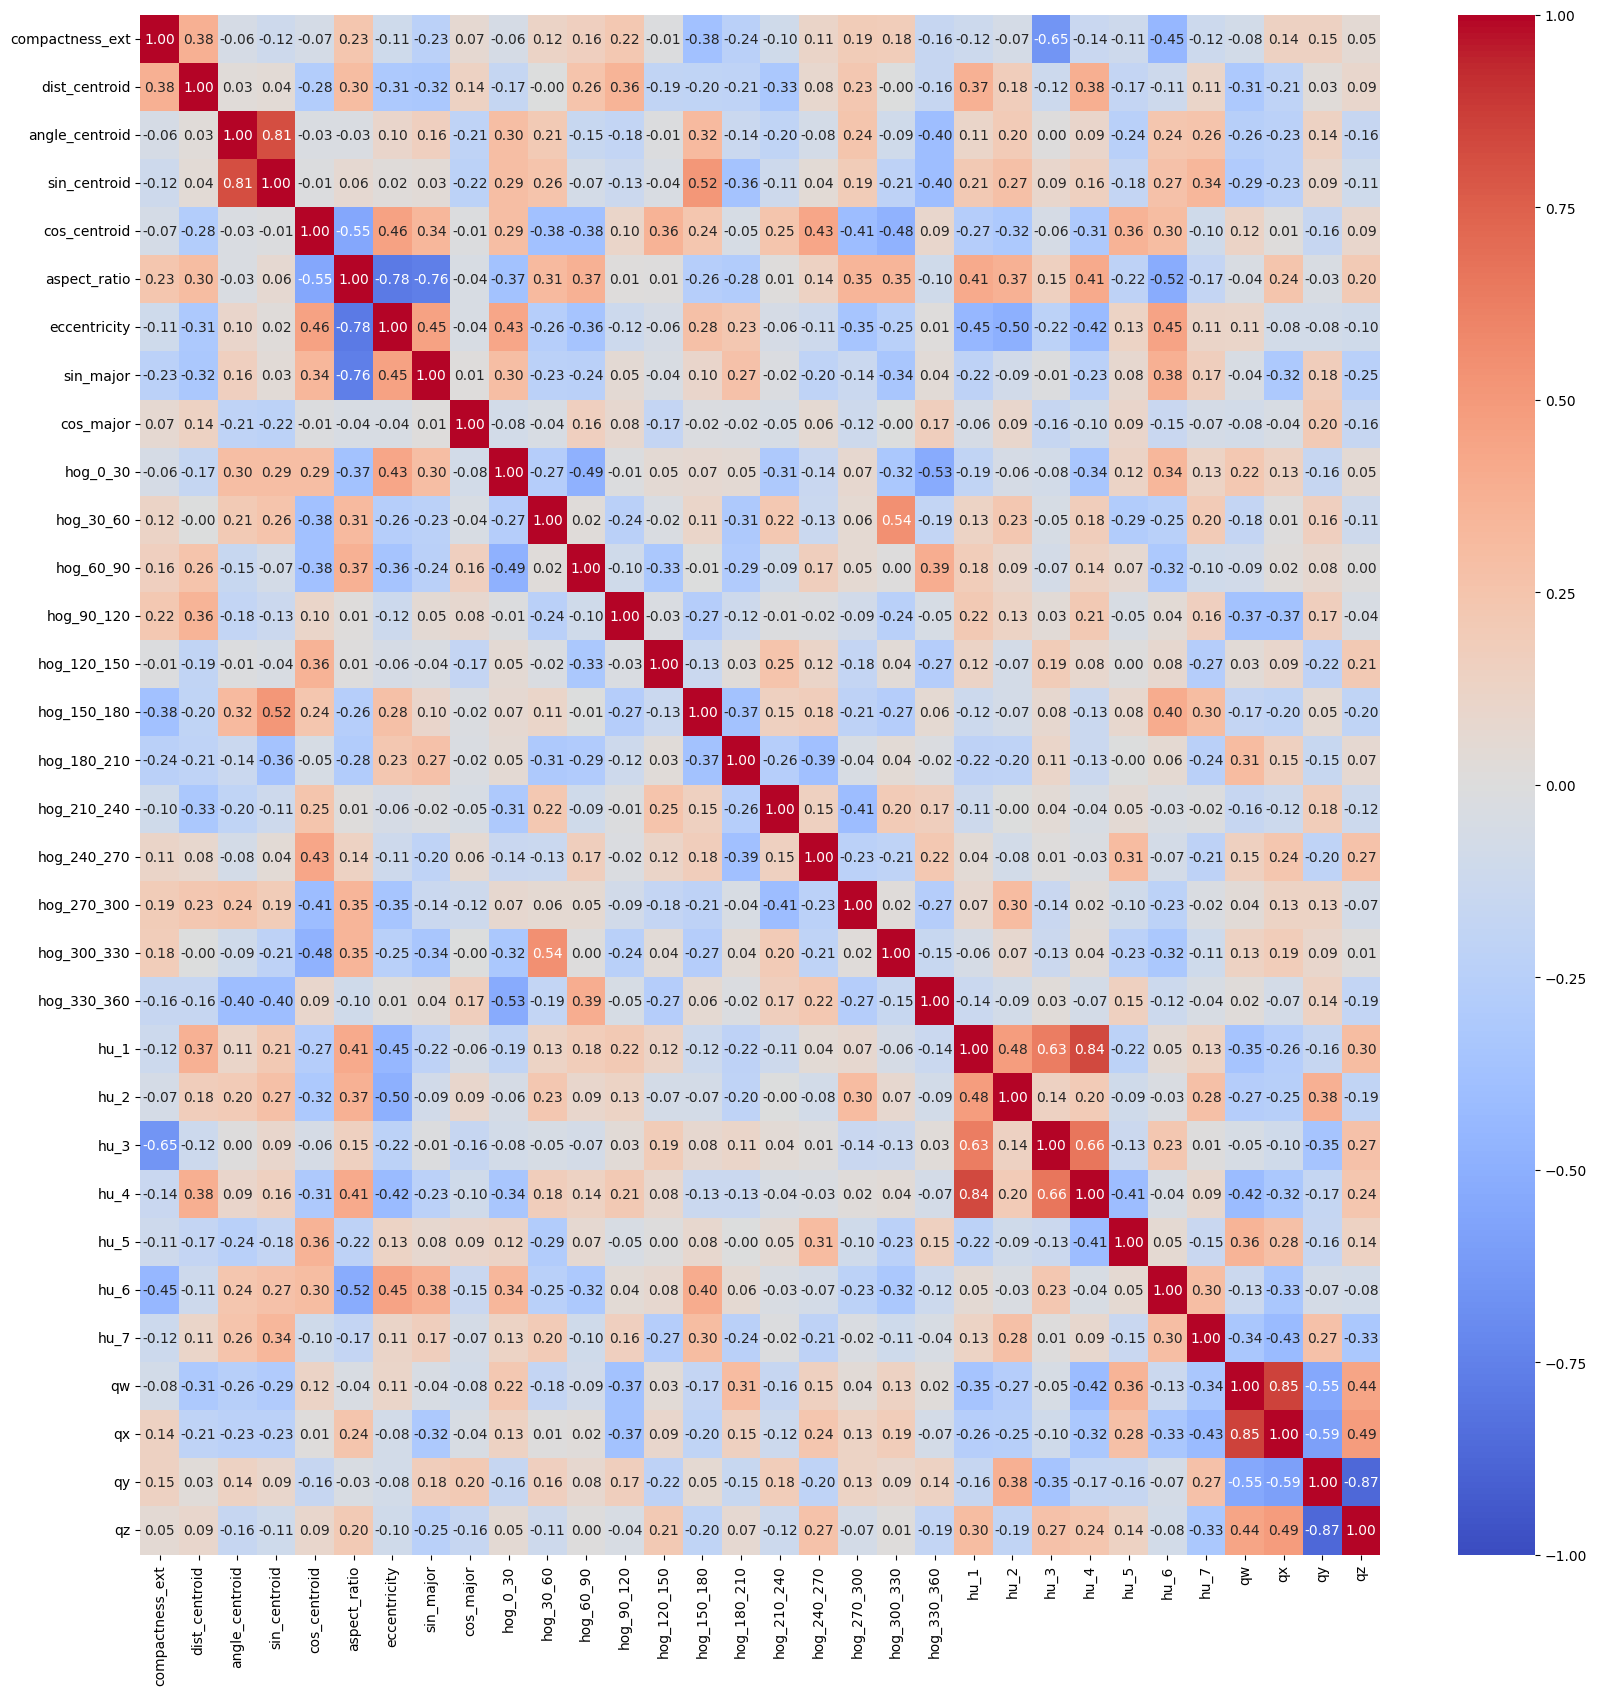

In [9]:
corr_matrix = train_df[X_cols + y_cols].corr('pearson')

plt.figure(0, figsize=(20, 20))
sns.heatmap(corr_matrix, vmin=-1, vmax=1, cmap='coolwarm', annot=True, fmt='.2f')

In [10]:
corr_pairs = (
    corr_matrix
    .where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    .stack()
    .reset_index()
)
corr_pairs.columns = ['var_1', 'var_2', 'correlation']
corr_pairs['abs_correlation'] = corr_pairs['correlation'].abs()
corr_pairs = corr_pairs.sort_values('abs_correlation', ascending=False).reset_index(drop=True)

print(corr_pairs.to_string(index=True))

                var_1            var_2  correlation  abs_correlation
0                  qy               qz    -0.869864         0.869864
1                  qw               qx     0.851932         0.851932
2                hu_1             hu_4     0.835569         0.835569
3      angle_centroid     sin_centroid     0.813723         0.813723
4        aspect_ratio     eccentricity    -0.783396         0.783396
5        aspect_ratio        sin_major    -0.758699         0.758699
6                hu_3             hu_4     0.659953         0.659953
7     compactness_ext             hu_3    -0.651909         0.651909
8                hu_1             hu_3     0.628520         0.628520
9                  qx               qy    -0.593085         0.593085
10       cos_centroid     aspect_ratio    -0.548647         0.548647
11                 qw               qy    -0.545629         0.545629
12          hog_30_60      hog_300_330     0.543125         0.543125
13           hog_0_30      hog_330

Variância explicada por componente:
  PC1: 67.14%  (acumulado: 67.14%)
  PC2: 21.36%  (acumulado: 88.51%)
  PC3: 8.71%  (acumulado: 97.21%)
  PC4: 2.79%  (acumulado: 100.00%)


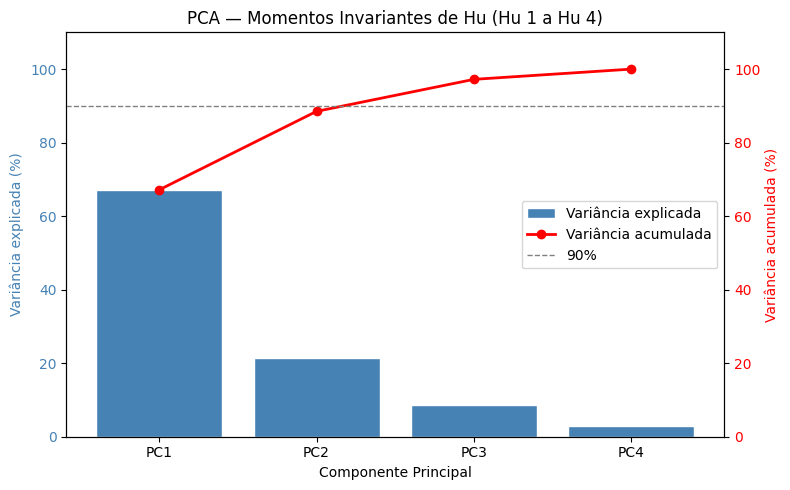

In [11]:
from sklearn.decomposition import PCA

hu_cols = ['hu_1', 'hu_2', 'hu_3', 'hu_4']

X_hu = X_train[hu_cols].values

pca = PCA(n_components=len(hu_cols))
pca.fit(X_hu)

explained     = pca.explained_variance_ratio_
explained_cum = np.cumsum(explained)
pc_labels     = [f'PC{i+1}' for i in range(len(hu_cols))]

print('Variância explicada por componente:')
for label, var, cum in zip(pc_labels, explained, explained_cum):
    print(f'  {label}: {var*100:.2f}%  (acumulado: {cum*100:.2f}%)')

fig, ax1 = plt.subplots(figsize=(8, 5))

ax1.bar(pc_labels, explained * 100, color='steelblue', edgecolor='white', label='Variância explicada')
ax1.set_xlabel('Componente Principal')
ax1.set_ylabel('Variância explicada (%)', color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')
ax1.set_ylim(0, 110)

ax2 = ax1.twinx()
ax2.plot(pc_labels, explained_cum * 100, color='red', marker='o', linewidth=2, label='Variância acumulada')
ax2.axhline(90, color='gray', linestyle='--', linewidth=1, label='90%')
ax2.set_ylabel('Variância acumulada (%)', color='red')
ax2.tick_params(axis='y', labelcolor='red')
ax2.set_ylim(0, 110)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='center right')

plt.title('PCA — Momentos Invariantes de Hu (Hu 1 a Hu 4)')
plt.tight_layout()
plt.savefig('../../../results/linear_regression/pca_hu_moments.png', dpi=150, bbox_inches='tight')
plt.show()

In [12]:
X_hu_pca_train = pca.transform(X_hu)
X_hu_pca_test = pca.transform(X_test[hu_cols].values)

X_train = X_train.drop(columns=hu_cols)
X_train['hu_pc1'] = X_hu_pca_train[:, 0]
X_train['hu_pc2'] = X_hu_pca_train[:, 1]

X_test = X_test.drop(columns=hu_cols)
X_test['hu_pc1'] = X_hu_pca_test[:, 0]
X_test['hu_pc2'] = X_hu_pca_test[:, 1]

X_cols = [col for col in X_cols if col not in hu_cols] + ['hu_pc1', 'hu_pc2']

Variância explicada por componente:
  PC1: 90.69%  (acumulado: 90.69%)
  PC2: 9.31%  (acumulado: 100.00%)


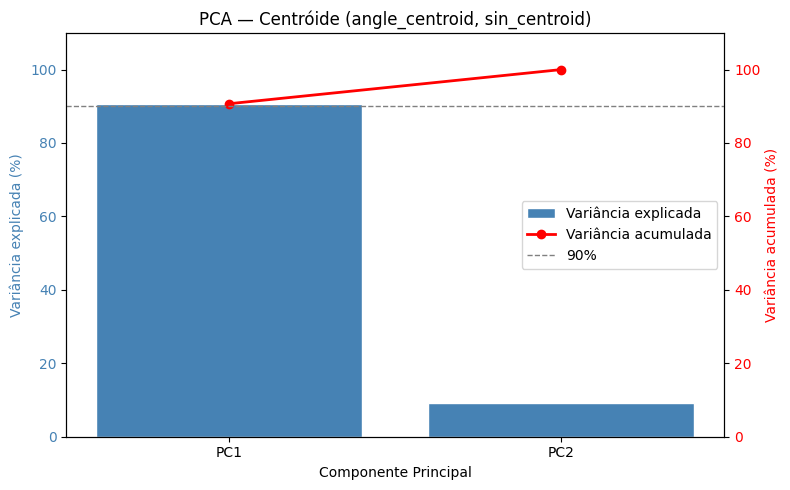

In [13]:
centroid_cols = ['angle_centroid', 'sin_centroid']

X_centroid = X_train[centroid_cols].values

pca_centroid = PCA(n_components=len(centroid_cols))
pca_centroid.fit(X_centroid)

explained     = pca_centroid.explained_variance_ratio_
explained_cum = np.cumsum(explained)
pc_labels     = [f'PC{i+1}' for i in range(len(centroid_cols))]

print('Variância explicada por componente:')
for label, var, cum in zip(pc_labels, explained, explained_cum):
    print(f'  {label}: {var*100:.2f}%  (acumulado: {cum*100:.2f}%)')

fig, ax1 = plt.subplots(figsize=(8, 5))
ax1.bar(pc_labels, explained * 100, color='steelblue', edgecolor='white', label='Variância explicada')
ax1.set_xlabel('Componente Principal')
ax1.set_ylabel('Variância explicada (%)', color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')
ax1.set_ylim(0, 110)

ax2 = ax1.twinx()
ax2.plot(pc_labels, explained_cum * 100, color='red', marker='o', linewidth=2, label='Variância acumulada')
ax2.axhline(90, color='gray', linestyle='--', linewidth=1, label='90%')
ax2.set_ylabel('Variância acumulada (%)', color='red')
ax2.tick_params(axis='y', labelcolor='red')
ax2.set_ylim(0, 110)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='center right')
plt.title('PCA — Centróide (angle_centroid, sin_centroid)')
plt.tight_layout()
plt.savefig('../../../results/linear_regression/pca_centroid.png', dpi=150, bbox_inches='tight')
plt.show()

In [14]:
X_centroid_pca_train = pca_centroid.transform(X_centroid)
X_centroid_pca_test  = pca_centroid.transform(X_test[centroid_cols].values)

X_train = X_train.drop(columns=centroid_cols)
X_train['centroid_pc1'] = X_centroid_pca_train[:, 0]

X_test = X_test.drop(columns=centroid_cols)
X_test['centroid_pc1'] = X_centroid_pca_test[:, 0]

X_cols = [col for col in X_cols if col not in centroid_cols] + ['centroid_pc1']

In [15]:
y_train.describe().T

,count,mean,std,min,25%,50%,75%,max
qw,1050.0,2.706829e-17,1.000477,-2.152411,-0.807731,0.031877,0.802434,1.871772
qx,1050.0,7.443781e-17,1.000477,-1.798965,-0.967849,0.308799,0.846219,1.596430
qy,1050.0,-9.473903e-17,1.000477,-1.758006,-0.956787,0.277305,0.857398,1.569891
qz,1050.0,-1.353415e-17,1.000477,-1.957458,-0.762555,-0.036737,0.771320,2.281407


In [16]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
X_test  = pd.DataFrame(scaler.transform(X_test),      columns=X_test.columns)

In [17]:
pt_pca = PowerTransformer(method='yeo-johnson', standardize=True)

pca_cols = ['hu_pc1', 'hu_pc2', 'centroid_pc1']

X_train[pca_cols] = pd.DataFrame(
    pt_pca.fit_transform(X_train[pca_cols]),
    columns=pca_cols,
    index=X_train.index
)
X_test[pca_cols] = pd.DataFrame(
    pt_pca.transform(X_test[pca_cols]),
    columns=pca_cols,
    index=X_test.index
)

array([[<Axes: title={'center': 'compactness_ext'}>,
        <Axes: title={'center': 'dist_centroid'}>,
        <Axes: title={'center': 'cos_centroid'}>,
        <Axes: title={'center': 'aspect_ratio'}>,
        <Axes: title={'center': 'eccentricity'}>],
       [<Axes: title={'center': 'sin_major'}>,
        <Axes: title={'center': 'cos_major'}>,
        <Axes: title={'center': 'hog_0_30'}>,
        <Axes: title={'center': 'hog_30_60'}>,
        <Axes: title={'center': 'hog_60_90'}>],
       [<Axes: title={'center': 'hog_90_120'}>,
        <Axes: title={'center': 'hog_120_150'}>,
        <Axes: title={'center': 'hog_150_180'}>,
        <Axes: title={'center': 'hog_180_210'}>,
        <Axes: title={'center': 'hog_210_240'}>],
       [<Axes: title={'center': 'hog_240_270'}>,
        <Axes: title={'center': 'hog_270_300'}>,
        <Axes: title={'center': 'hog_300_330'}>,
        <Axes: title={'center': 'hog_330_360'}>,
        <Axes: title={'center': 'hu_5'}>],
       [<Axes: title={'cen

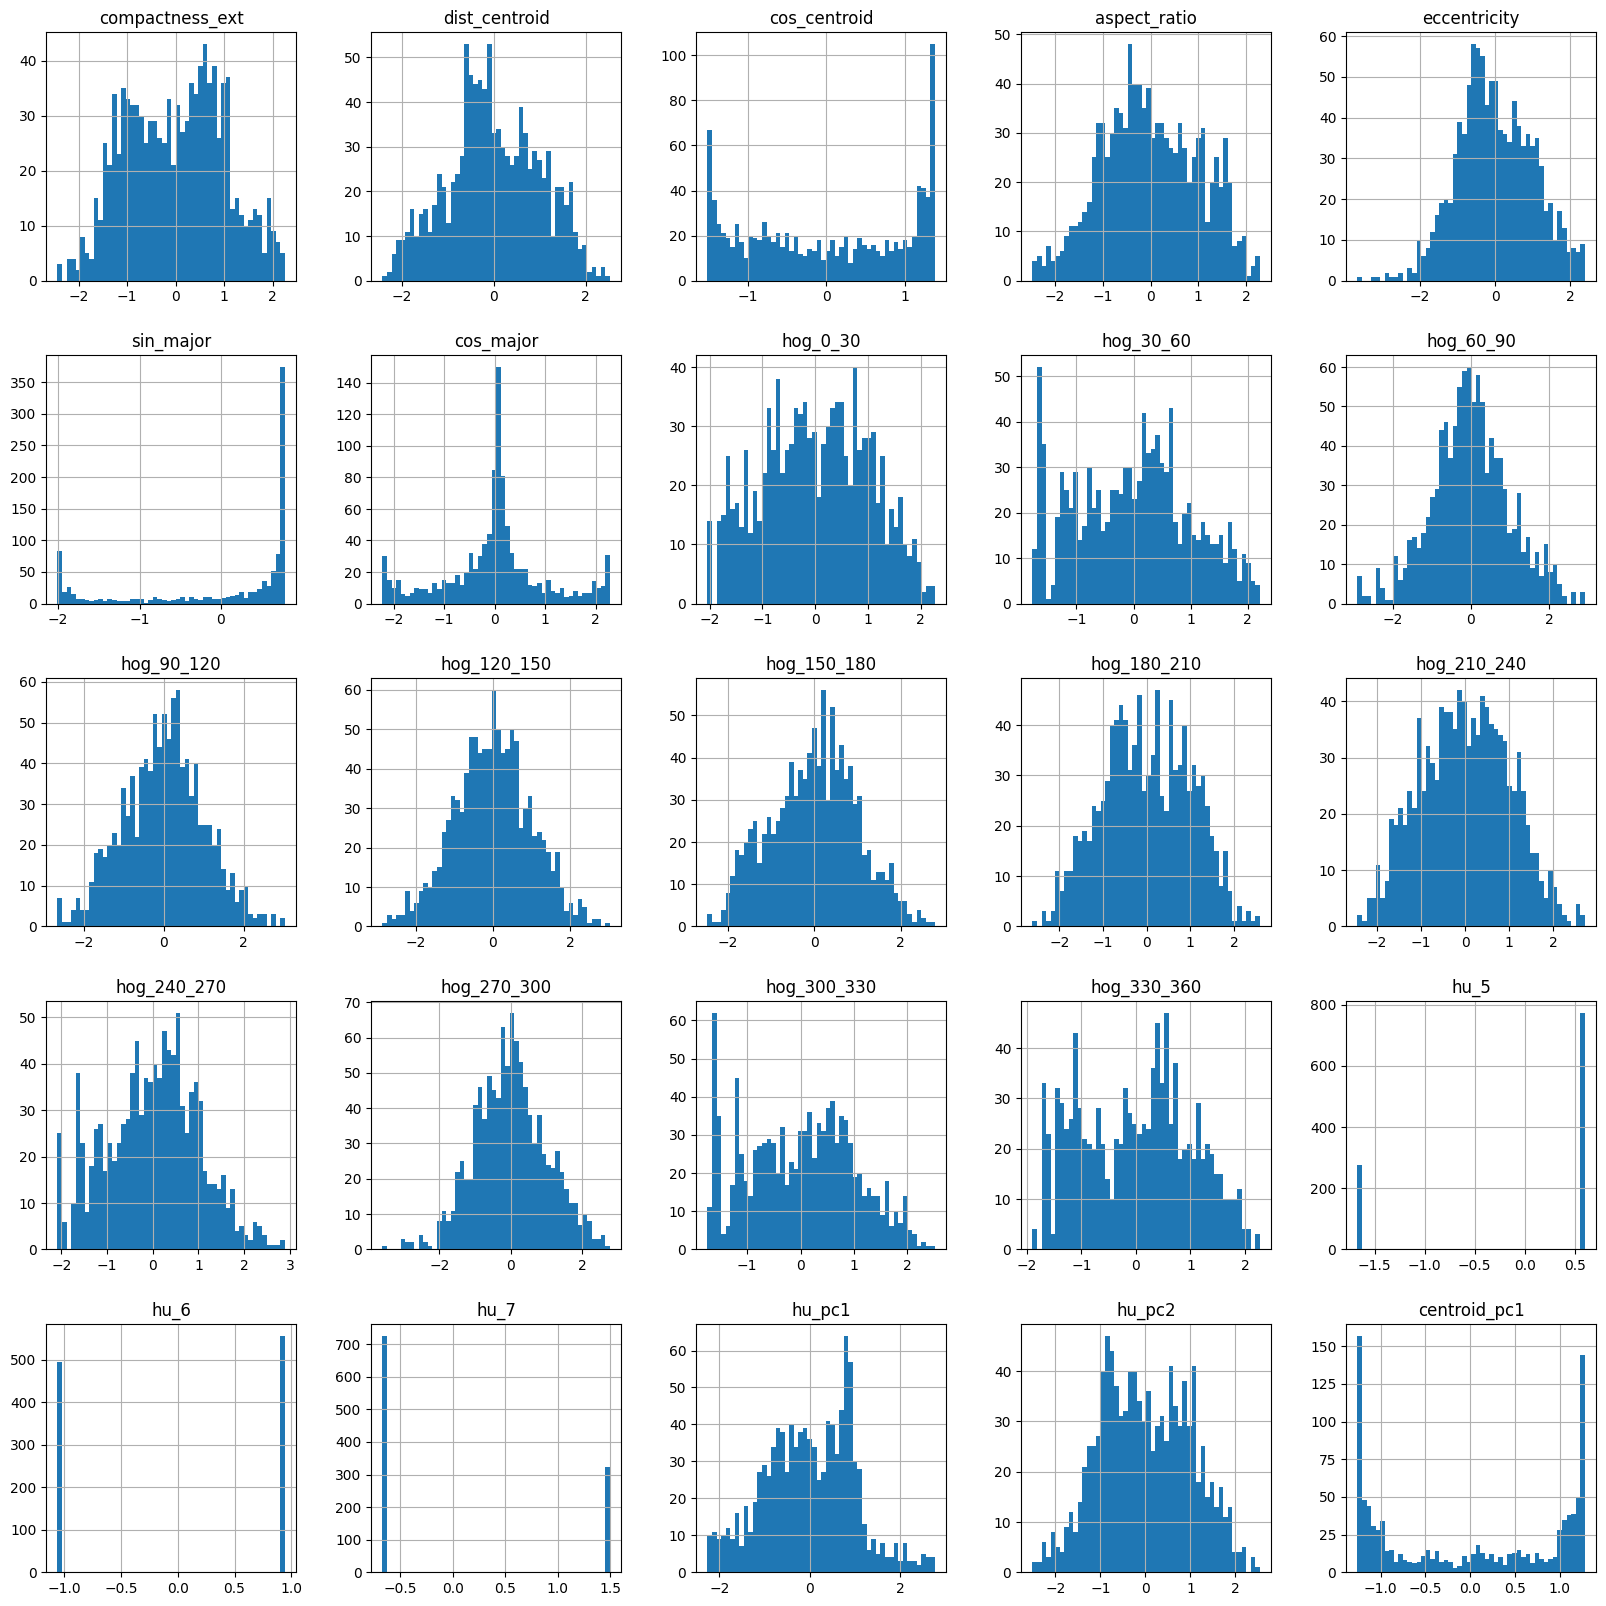

In [18]:
X_train.hist(bins=50, figsize=(20, 20))

In [19]:
X_test.describe().T

,count,mean,std,min,25%,50%,75%,max
compactness_ext,263.0,-0.062787,1.064323,-2.331574,-0.945354,0.051684,0.799366,2.142427
dist_centroid,263.0,-0.046901,0.994480,-2.391953,-0.701909,-0.094774,0.646921,2.657760
cos_centroid,263.0,0.025630,1.004864,-1.514040,-0.910582,0.042984,1.051167,1.383739
aspect_ratio,263.0,0.038944,1.015132,-2.375782,-0.814283,0.038855,0.885003,2.041390
eccentricity,263.0,0.029773,0.992252,-3.162131,-0.624673,0.013305,0.752929,2.334032
sin_major,263.0,-0.100481,1.055981,-2.008030,-0.948099,0.496033,0.759858,0.782921
cos_major,263.0,-0.039673,1.073192,-2.219197,-0.561916,0.010178,0.387754,2.279152
hog_0_30,263.0,-0.010649,0.997158,-1.995807,-0.804174,-0.055697,0.680365,2.396885
hog_30_60,263.0,-0.086440,1.014927,-1.727494,-1.029088,-0.035793,0.576290,2.120523
hog_60_90,263.0,-0.050688,1.034643,-2.927456,-0.746156,-0.052453,0.608657,2.665948


In [20]:
from sklearn.linear_model import LinearRegression
from sklearn.multioutput import MultiOutputRegressor

model = MultiOutputRegressor(LinearRegression())
model.fit(X_train[X_cols], y_train[y_cols])

y_pred = model.predict(X_test[X_cols])
y_pred = y_pred / np.linalg.norm(y_pred, axis=1, keepdims=True)

errors = np.array([geodesic_error(y_test[y_cols].values[i], y_pred[i]) for i in range(len(y_test))])

print(f'Erro geodésico médio:   {errors.mean():.2f} graus')
print(f'Erro geodésico mediano: {np.median(errors):.2f} graus')
print(f'Erro geodésico std:     {errors.std():.2f} graus')
print(f'Erro geodésico mínimo:  {errors.min():.2f} graus')
print(f'Erro geodésico máximo:  {errors.max():.2f} graus')

Erro geodésico médio:   22.82 graus
Erro geodésico mediano: 0.00 graus
Erro geodésico std:     45.34 graus
Erro geodésico mínimo:  0.00 graus
Erro geodésico máximo:  178.71 graus
